# Random Forest 

This notebook is used in the second week of Spiced Academy's Data Science Bootcamp.


## Data Set 1: Titanic from Kaggle

- The data was downloaded from Kaggle on the 27.02.2020:

    https://www.kaggle.com/c/titanic/

- **Variable Notes**

    - pclass: A proxy for socio-economic status (SES)
        - 1st = Upper
        - 2nd = Middle
        - 3rd = Lower

    - age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

    - sibsp: Siblings and spouse
    - parch: Parent child
    - Parent = mother, father
    - Child = daughter, son, stepdaughter, stepson
    - Some children travelled only with a nanny, therefore parch=0 for them.

## Decision Tree


## Random Forest

   - Improving the results from a single decision tree using bootstrapping both for data and features.



PSEUDO-CODE 



** MACHINE LEARNING - CLASSIFICATION **





1. Read data in.

2. 

-------------------------------------------------

## A DECISION TREE

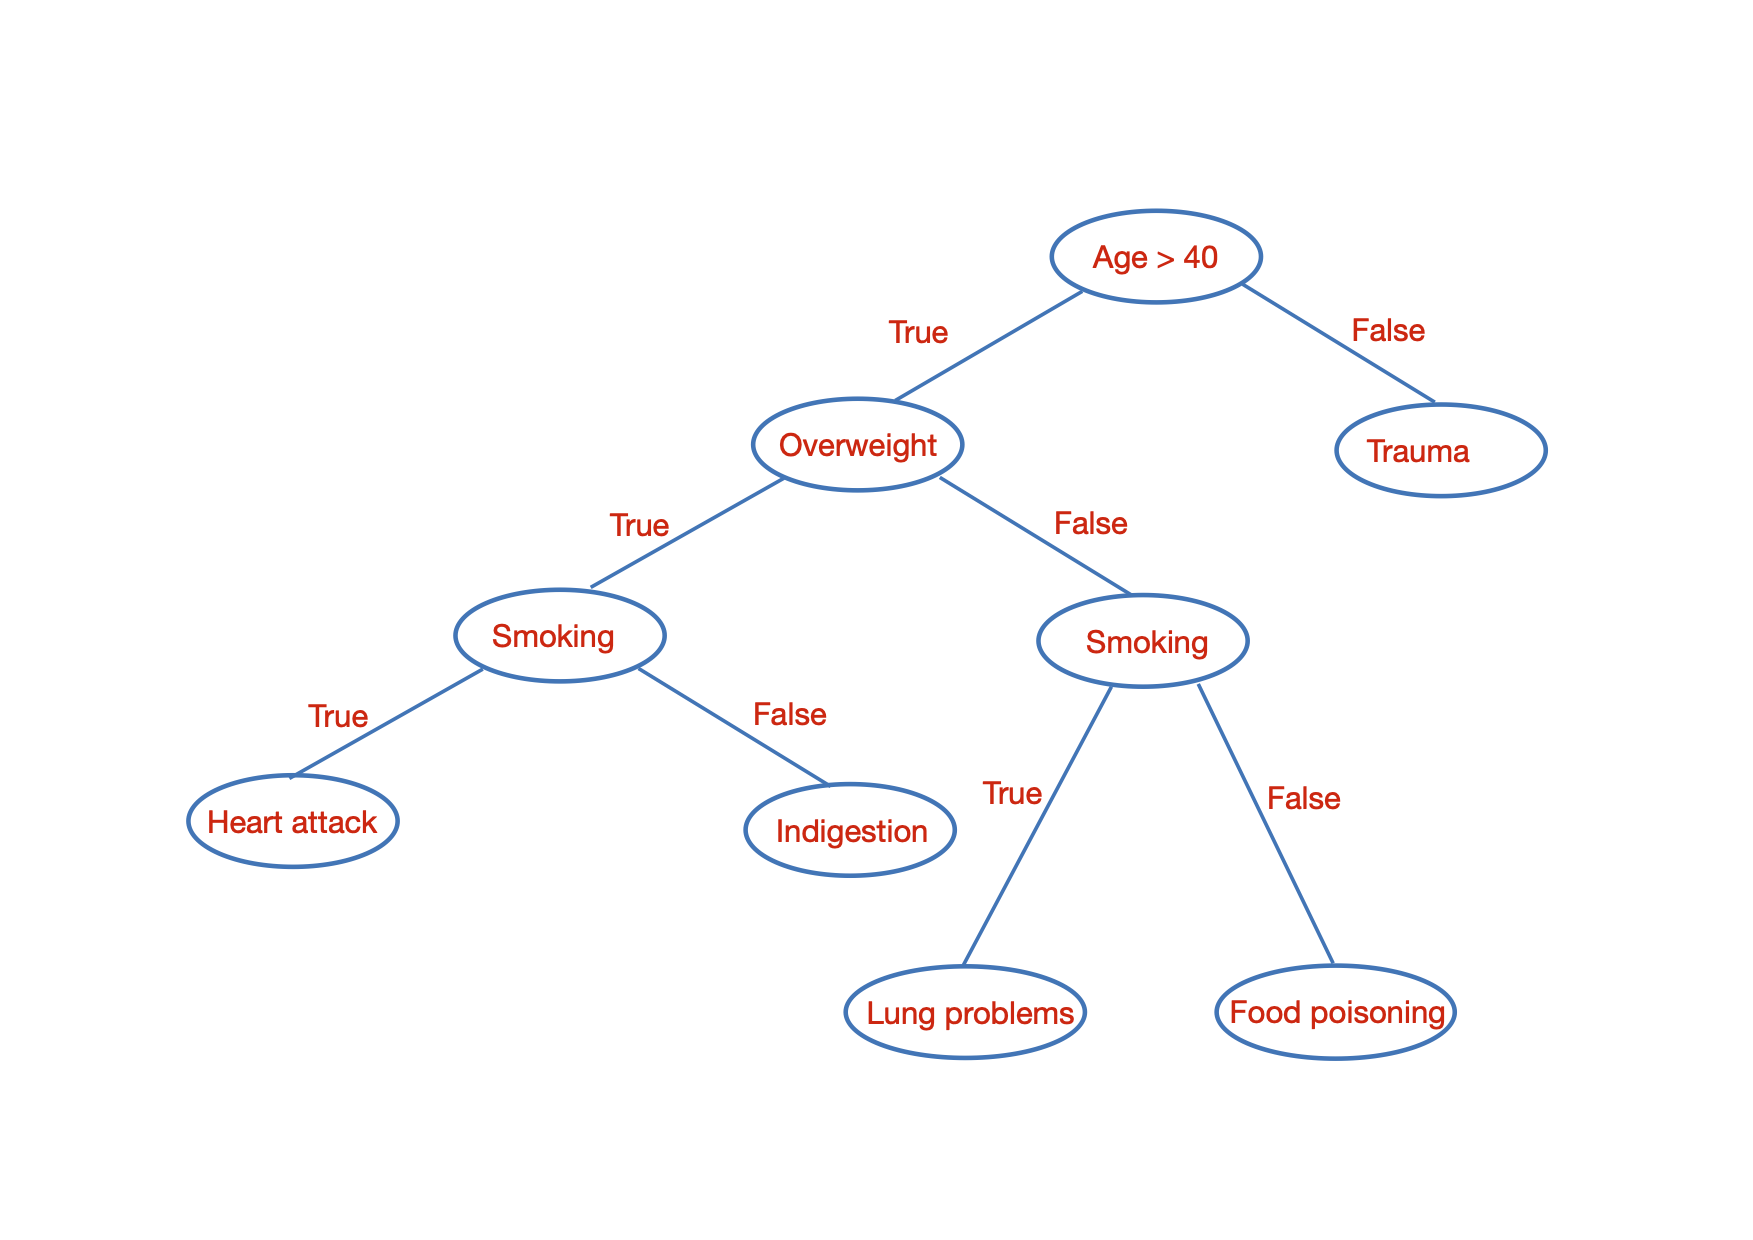

In [1]:
from IPython.display import Image

Image("../../Figures/tree.png" )

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score,confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Only need this part for windows
#import os
#os.environ["PATH"] += os.pathsep + 'C:/ProgramData/Anaconda3/Library/bin/graphviz/'



In [3]:
df = pd.read_csv('../data/titanic/train.csv', index_col=0)
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [4]:
for index, row in df.iterrows():
    if index == 2:
        print(index, '\n', row)
    

2 
 Survived                                                    1
Pclass                                                      1
Name        Cumings, Mrs. John Bradley (Florence Briggs Th...
Sex                                                    female
Age                                                      38.0
SibSp                                                       1
Parch                                                       0
Ticket                                               PC 17599
Fare                                                  71.2833
Cabin                                                     C85
Embarked                                                    C
Name: 2, dtype: object


In [ ]:
df.describe()

In [8]:
# You won't have to do this normally manually.

y = df['Survived'] #labels, true

ypred = [] #fill in this list of predictions with 1s (survived) and 0s 

for i, row in df.iterrows():   
    if row['Sex'] == 'female':
        if row['Pclass'] < 3: 
            if row['Parch'] < 4: 
                ypred.append(1)
            else:
                ypred.append(0)
        else:          
            ypred.append(0)
    else:
        ypred.append(0)

In [10]:
print(accuracy_score(y, ypred))


0.7867564534231201


**Out of the box from sklearn**

In [14]:
from sklearn.tree import DecisionTreeClassifier

#from sklearn.linear_model import LogisticRegression
df['Sex'].replace('female', 0, inplace=True)
df['Sex'].replace('male', 1, inplace=True)

X = df[['Parch','Sex', 'Pclass']]
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state = 100)

m_dt = DecisionTreeClassifier()

m_dt.fit(x_train, y_train)
m_dt.predict(x_train)
m_dt.predict(x_test)
m_dt.score(x_train, y_train), m_dt.score(x_test,y_test)

(0.8158682634730539, 0.7757847533632287)

In [ ]:
M1 (overfit)
train=0.8 test=0.55

M2 (underfit)
train=0.55 test=0.6

### Bias Variance Trade-off


https://towardsdatascience.com/understanding-the-bias-variance-tradeoff-165e6942b229

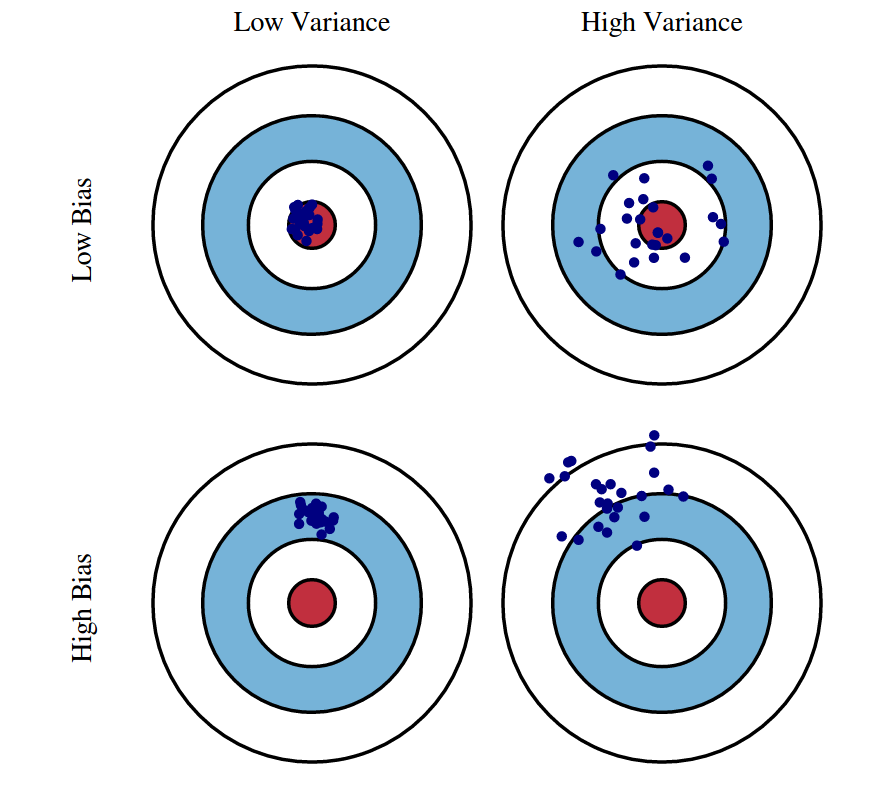

In [16]:
Image("../../Figures/bias_variance_tradeoff_cornell.png" )



# Random Forest

Random forest is an ensemble method that combines multiple decision trees in order to increase the performance of the tree.

**Bootstrapping**

x = [1,2,3,4,5]

subsample_1 = [1,3,3,4,3]

subsample_2 = [1,4,5,3,1]

subsample_3 = [2,3,4,2,2]

   **Bias-Variance Tradeoff Reminder** 
   - In machine learning **a model that fits training data poorly has high bias, while a model that overfits the training, however fails to generalise to the test data has high variance**. We would like to find the right balance between these: Having a model that can fit our training data but which also generalises well.

   
   **Relation to Random Forest**
   -  Depth: A single decision tree is likely to overfit unless it has depth limit. However limiting the depth might decrease the prediction power very significantly.
    
   - Random forest overcomes the above problem by combining several trees together, of which the average result would emulate the true values.
    
       - For each tree a subset of the data and the features are used. The selection is done with **bootstrapping** (sampling with replacement) to decrease the variance  without increasing bias. While each tree might still overfit, since we are using many trees with different samples, their average comes over the problem of high bias, without increasing the variance.
       
       - To overcome the **correlation between trees**, RF is choosing a **random sample of the features** at every split.
   
   - An article (just for the very curious) about a real life data experiment comparing RF to Logistic Regression showed that although RF performed better, the results were dependent on the inclusion criteria: https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-018-2264-5
   
   - Wikipedia article on random forest is nice for some basics.
   
   - And this one is a nice article: https://machinelearningmastery.com/bagging-and-random-forest-ensemble-algorithms-for-machine-learning/
   

# Example

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y, random_state = 10)

In [30]:
x_train.head(2)

,Parch,Sex,Pclass
PassengerId,,,
579,0,0,3
324,1,0,2


In [31]:
y_test.head(2)

PassengerId
591    0
132    0
Name: Survived, dtype: int64

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [33]:
rf = RandomForestClassifier(max_depth=3,n_estimators=1000 )
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

In [34]:
y_pred[:5], y_test[:5]

(array([0, 0, 0, 1, 1]),
 PassengerId
 591    0
 132    0
 629    0
 196    1
 231    1
 Name: Survived, dtype: int64)

In [35]:
rf.score(x_train,y_train), rf.score(x_test,y_test)

(0.7919161676646707, 0.8340807174887892)

In [ ]:
# graphviz for tree visualisation.

**Which features are more important?**

In [37]:
feature_label = pd.DataFrame(x_train).columns

# This is a very useful method!
feature_importance = rf.feature_importances_

print(feature_label, feature_importance)



Index(['Parch', 'Sex', 'Pclass'], dtype='object') [0.08617349 0.62198176 0.29184476]


#### CHECK THE DIFFERENCE WITH THE DECISION TREE

In [25]:
dm = DecisionTreeClassifier(random_state=10)
dm.fit(x_train,y_train)
y_pred=dm.predict(x_test)
print(dm.score(x_train, y_train),dm.score(x_test,y_test))

0.8158682634730539 0.7757847533632287


-----------

-----------